
# ACC102 Track 2 Mini Assignment
# Title：Correlation Analysis Between Long-term Corporate Profitability and ESG Performance of Chinese A-share Listed Companies
# Author: Yilin Cao
# Data Source：WRDS CSMAR (Financial Data) + Wind Local Excel (ESG Data)
# Analysis Tools：Python (pandas, numpy, matplotlib, seaborn, statsmodels)
# =============================================================================

In [1]:
!pip install statsmodels

In [2]:
#  Import Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os

In [3]:
# Part 1: Pull Financial Data & Calculate ROE from WRDS CSMAR
# =============================================================================
# Connect to WRDS Database
import wrds
db = wrds.Connection(wrds_username="yilincao") 


Loading library list...
Done


In [4]:
# Pull A-share Financial Panel Data (2020-2025)
sql_query = """
SELECT stkcd, accper, typrep, a001000000, a002000000, a003000000
FROM csmar.wrds_csmar_financial_master
WHERE accper >= '2020-01-01' AND accper <= '2025-12-31'
"""
data = db.raw_sql(sql_query)

print(f"Total rows of raw financial data: {len(data)}")
data.head()

Total rows of raw financial data: 218324


,stkcd,accper,typrep,a001000000,a002000000,a003000000
0,000001,2020-01-01,A,3939070000000.0,3626087000000.0,312983000000.0
1,000001,2020-01-01,B,3939070000000.0,3626087000000.0,312983000000.0
2,000001,2020-03-31,A,4132298000000.0,3779943000000.0,352355000000.0
3,000001,2020-06-30,A,4178622000000.0,3827225000000.0,351397000000.0
4,000001,2020-09-30,A,4346921000000.0,3988150000000.0,358771000000.0


In [5]:
# Keep Only Annual Official Year-End Reports
data = data[data['typrep'] == 'A'].copy()

# Convert Accounting Date to Datetime Format
data['accper'] = pd.to_datetime(data['accper'])

# Core Filter: Keep Only December Year-End Reports
data = data[data['accper'].dt.month == 12].copy()

# Extract Year
data['year'] = data['accper'].dt.year

# Keep Complete Year Range 2020-2024
data = data[(data['year'] >= 2020) & (data['year'] <= 2024)].reset_index(drop=True)

# Calculate ROE (Net Income / Total Shareholder Equity)
data['roe'] = data['a001000000'] / data['a003000000']

print(f"Sample size after year-end filtering:{len(data)}")
print("\nSample distribution by year:")
print(data['year'].value_counts().sort_index())

data.head()

Sample size after year-end filtering:25802

Sample distribution by year:
year
2020    4589
2021    5012
2022    5279
2023    5440
2024    5482
Name: count, dtype: int64


,stkcd,accper,typrep,a001000000,a002000000,a003000000,year,roe
0,000001,2020-12-31,A,4468514000000.0,4104383000000.0,364131000000.0,2020,12.271721
1,000001,2021-12-31,A,4921380000000.0,4525932000000.0,395448000000.0,2021,12.445075
2,000001,2022-12-31,A,5321514000000.0,4886834000000.0,434680000000.0,2022,12.242371
3,000001,2023-12-31,A,5587116000000.0,5114788000000.0,472328000000.0,2023,11.82889
4,000001,2024-12-31,A,5769270000000.0,5274428000000.0,494842000000.0,2024,11.658812


In [6]:
# Drop Unused Raw Date Column
data = data.drop(columns=['accper'])

# Group by Stock Code + Year, Calculate Annual Average ROE
data_year = data.groupby(['stkcd','year'], as_index=False)['roe'].mean()

# Rename Column
data_year = data_year.rename(columns={'roe':'roe_year_mean'})

print(f"Sample size after group aggregation: {len(data_year)}")
print("\nYearly sample distribution:")
print(data_year['year'].value_counts().sort_index())

data_year.head()

Sample size after group aggregation: 25802

Yearly sample distribution:
year
2020    4589
2021    5012
2022    5279
2023    5440
2024    5482
Name: count, dtype: int64


,stkcd,year,roe_year_mean
0,000001,2020,12.271721
1,000001,2021,12.445075
2,000001,2022,12.242371
3,000001,2023,11.82889
4,000001,2024,11.658812


In [7]:
# Calculate 5-Year Average ROE for Each Individual Firm
firm_roe_5y_avg = data_year.groupby('stkcd', as_index=False)['roe_year_mean'].mean()

# Rename Column
firm_roe_5y_avg = firm_roe_5y_avg.rename(columns={'roe_year_mean':'roe_5y_avg_2020_2024'})

print(f"Total number of listed firms after aggregation: {len(firm_roe_5y_avg)}")
firm_roe_5y_avg.head()

Total number of listed firms after aggregation: 5664


,stkcd,roe_5y_avg_2020_2024
0,000001,12.089374
1,000002,4.429593
2,000004,2.055501
3,000005,1.838641
4,000006,2.895996


In [3]:
# -----------------------------------------------------------------------------
# Part 2: Import & Clean Wind ESG Dataset
# -----------------------------------------------------------------------------
# Read Excel with relative path
df_esg = pd.read_excel(
    "WindESG_2020_2025.xlsx",
    header = 0,
    dtype = str
)

print(f"Original ESG raw sample size:{len(df_esg)}")
df_esg.head()

Original ESG raw sample size:5389


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,证券代码,评级日期,ESG评级,ESG综合得分\n2026.04.21,环境得分,社会得分,治理得分
1,600355.SH,2026-04-21,D,4.31,0.00,1.81,4.86
2,603007.SH,2026-04-21,B,4.37,0.00,2.16,4.35
3,600358.SH,2026-04-20,B,4.24,0.00,0.75,3.96
4,688270.SH,2026-04-18,D,3.93,0.51,3.18,6.73


In [9]:
# Fix Header Structure
df_esg.columns = df_esg.iloc[0] 
df_esg = df_esg[1:].reset_index(drop=True)  

# Clean Stock Code (Remove Suffix, Keep Only 6 Digits)
df_esg['stkcd'] = df_esg['证券代码'].astype(str).str.extract(r'(\d{6})')

# Filter Pure A-share Listed Companies
df_esg = df_esg[df_esg['stkcd'].notna()].reset_index(drop=True)

# Convert Date & Extract Year
df_esg['rating_date'] = pd.to_datetime(df_esg['评级日期'], errors='coerce')
df_esg['year'] = df_esg['rating_date'].dt.year.astype(int)

# Keep Only Year 2025 ESG Data
df_esg_2025 = df_esg[df_esg['year'] == 2025].reset_index(drop=True)

print(f"Filtered 2025 ESG sample size: {len(df_esg_2025)}")
print("\nYear distribution check:")
print(df_esg_2025['year'].value_counts())

df_esg_2025.head()

Filtered 2025 ESG sample size: 5331

Year distribution check:
year
2025    5331
Name: count, dtype: int64


,证券代码,评级日期,ESG评级,ESG综合得分\n2026.04.21,环境得分,社会得分,治理得分,stkcd,rating_date,year
0,002015.SZ,2025-12-31,BB,6.70,6.00,6.06,6.97,002015,2025-12-31,2025
1,002055.SZ,2025-12-31,D,6.45,5.49,5.73,6.86,002055,2025-12-31,2025
2,688366.SH,2025-12-29,BBB,7.19,5.84,6.69,6.75,688366,2025-12-29,2025
3,000415.SZ,2025-12-23,D,6.35,2.90,3.26,7.95,000415,2025-12-23,2025
4,300173.SZ,2025-12-20,D,6.86,5.91,5.52,6.86,300173,2025-12-20,2025


In [10]:
# Keep Only Required ESG Dimension Columns
df_esg_clean = df_esg_2025[['stkcd', 'ESG综合得分\n2026.04.21', '环境得分', '社会得分', '治理得分']].copy()

# Shorten Column Names
df_esg_clean = df_esg_clean.rename(columns={
    'ESG综合得分\n2026.04.21': 'esg_total',
    '环境得分': 'env_score',
    '社会得分': 'soc_score',
    '治理得分': 'gov_score'
})

print(f"Final cleaned ESG dataset size: {len(df_esg_clean)}")
df_esg_clean.head()

Final cleaned ESG dataset size: 5331


,stkcd,esg_total,env_score,soc_score,gov_score
0,002015,6.70,6.00,6.06,6.97
1,002055,6.45,5.49,5.73,6.86
2,688366,7.19,5.84,6.69,6.75
3,000415,6.35,2.90,3.26,7.95
4,300173,6.86,5.91,5.52,6.86


In [11]:
# -----------------------------------------------------------------------------
# Part 3: Merge ROE & ESG Datasets
# -----------------------------------------------------------------------------
df_final = pd.merge(
    firm_roe_5y_avg,
    df_esg_clean,
    on = 'stkcd',
    how = 'inner'
)

print(f"Final matched ESG + ROE sample size: {len(df_final)}")

df_final.head()

Final matched ESG + ROE sample size: 5081


,stkcd,roe_5y_avg_2020_2024,esg_total,env_score,soc_score,gov_score
0,000001,12.089374,7.17,7.99,5.03,8.00
1,000002,4.429593,9.28,9.77,8.57,8.92
2,000004,2.055501,5.41,0.00,3.03,5.09
3,000006,2.895996,6.94,3.51,6.50,7.70
4,000007,3.434968,4.30,1.97,0.22,4.44


In [12]:
# Drop Rows With Missing Core Values
df_final = df_final.dropna(
    subset=['roe_5y_avg_2020_2024', 'esg_total', 'env_score', 'soc_score', 'gov_score']
).reset_index(drop=True)

print(f"Sample size after removing missing values: {len(df_final)}")

Sample size after removing missing values: 5081


In [13]:
# Convert Values to Numeric Type
df_final['esg_total'] = pd.to_numeric(df_final['esg_total'], errors='coerce')
df_final['roe_5y_avg_2020_2024'] = pd.to_numeric(df_final['roe_5y_avg_2020_2024'], errors='coerce')

df_final = df_final.dropna(
    subset=['roe_5y_avg_2020_2024', 'esg_total']
).reset_index(drop=True)

# 1% Winsorization to Remove Extreme Outliers
def winsorize_1p(series):
    q01 = series.quantile(0.01)
    q99 = series.quantile(0.99)
    return series.clip(q01, q99)

df_final['roe_clean'] = winsorize_1p(df_final['roe_5y_avg_2020_2024'])
df_final['esg_clean'] = winsorize_1p(df_final['esg_total'])


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

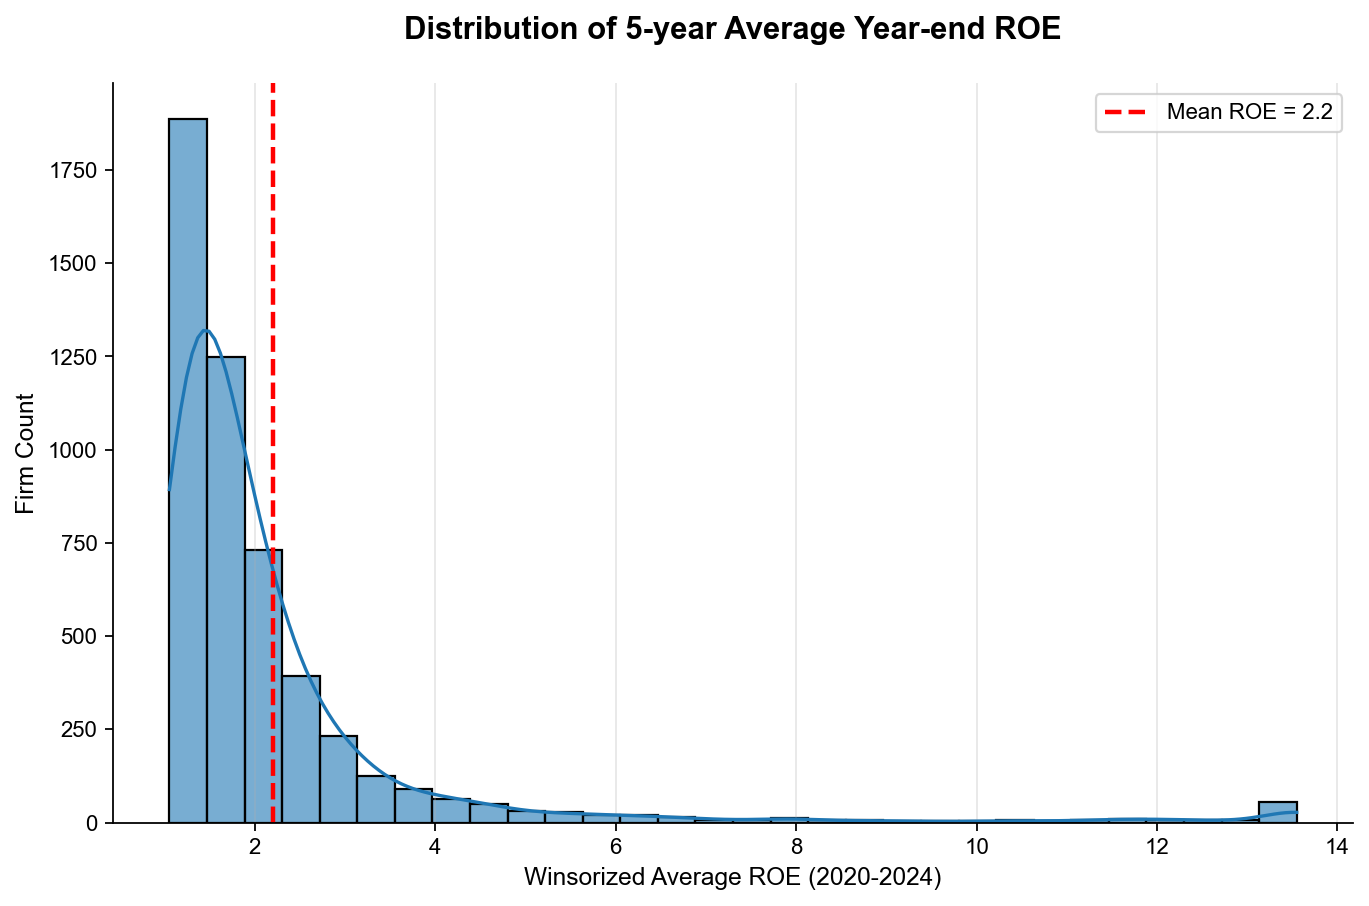

In [15]:
# -----------------------------------------------------------------------------
# Part 4: Descriptive Distribution Charts (Data Quality Check)
# -----------------------------------------------------------------------------

# Chart 1:Total ROE Distribution Histogram
plt.figure(figsize=(10,6), dpi=160)
plt.rcParams['font.family'] = 'Arial'

sns.histplot(df_final['roe_clean'], kde=True, color='#1f77b4', alpha=0.6, bins=30)

plt.title('Distribution of 5-year Average Year-end ROE', fontsize=14, weight='bold', pad=20)
plt.xlabel('Winsorized Average ROE (2020-2024)', fontsize=11)
plt.ylabel('Firm Count', fontsize=11)
plt.grid(axis='x', alpha=0.3)
sns.despine()

plt.axvline(df_final['roe_clean'].mean(), color='red', linestyle='--', lw=2,
            label=f'Mean ROE = {round(df_final["roe_clean"].mean(),2)}')
plt.legend()

# plt.savefig('roe_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

Chart 1:ROE Distribution Histogram

This histogram illustrates the overall distribution of the 5-year average year-end ROE after winsorization at the 1% level. It verifies that extreme outliers have been effectively removed and the profitability data is reasonable for subsequent correlation analysis.

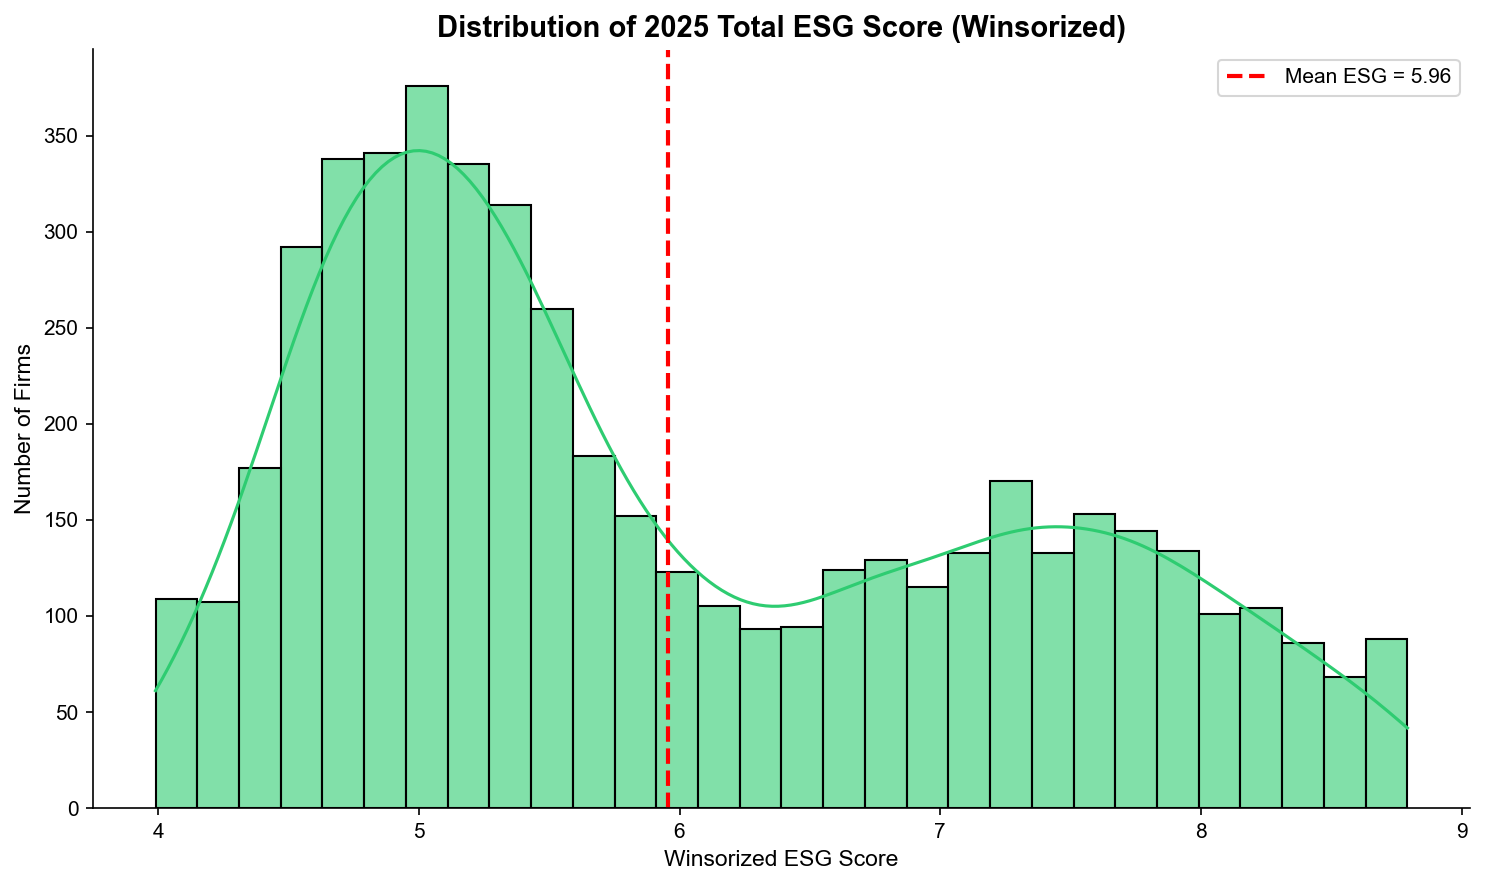

In [16]:
# Chart 2: ESG Score Distribution Histogram
plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(10,6), dpi=150)

sns.histplot(df_final['esg_clean'], kde=True, color='#2ecc71', alpha=0.6, bins=30)

mean_esg = df_final['esg_clean'].mean()
plt.axvline(mean_esg, color='red', linestyle='--', linewidth=2,
           label=f'Mean ESG = {mean_esg:.2f}')

plt.title('Distribution of 2025 Total ESG Score (Winsorized)', fontsize=14, weight='bold')
plt.xlabel('Winsorized ESG Score', fontsize=11)
plt.ylabel('Number of Firms', fontsize=11)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

Chart 2:ESG Score Distribution

This histogram displays the distribution of the 2025 total ESG scores for all sample firms after 1% winsorization (to mitigate the impact of extreme outliers). It includes a kernel density estimation (KDE) curve to show the overall shape of the distribution, as well as a dashed red line marking the mean ESG score of the cleaned sample.

In [17]:
# -----------------------------------------------------------------------------
# Part 5: Correlation Calculation
# -----------------------------------------------------------------------------
# Calculate Correlation
import scipy.stats as stats
corr, p_value = stats.pearsonr(df_final['roe_clean'], df_final['esg_clean'])
print(f"Pearson Correlation r={corr:.3f}, p-value={p_value:.4f}")

Pearson Correlation r=0.042, p-value=0.0025


The Pearson correlation coefficient between firms' 5-year average year-end ROE (2020–2024) and 2025 total ESG performance is r = 0.042, p = 0.0025.
The result is statistically significant at the 1% confidence level. However, the practical economic relationship between long-term profitability and ESG performance is extremely weak. This demonstrates that a company’s historical financial return barely explains its ESG rating in the Chinese A-share market.

Sample size after cleaning and winsorization: 5081
Pearson correlation coefficient between ESG and ROE: 0.0423


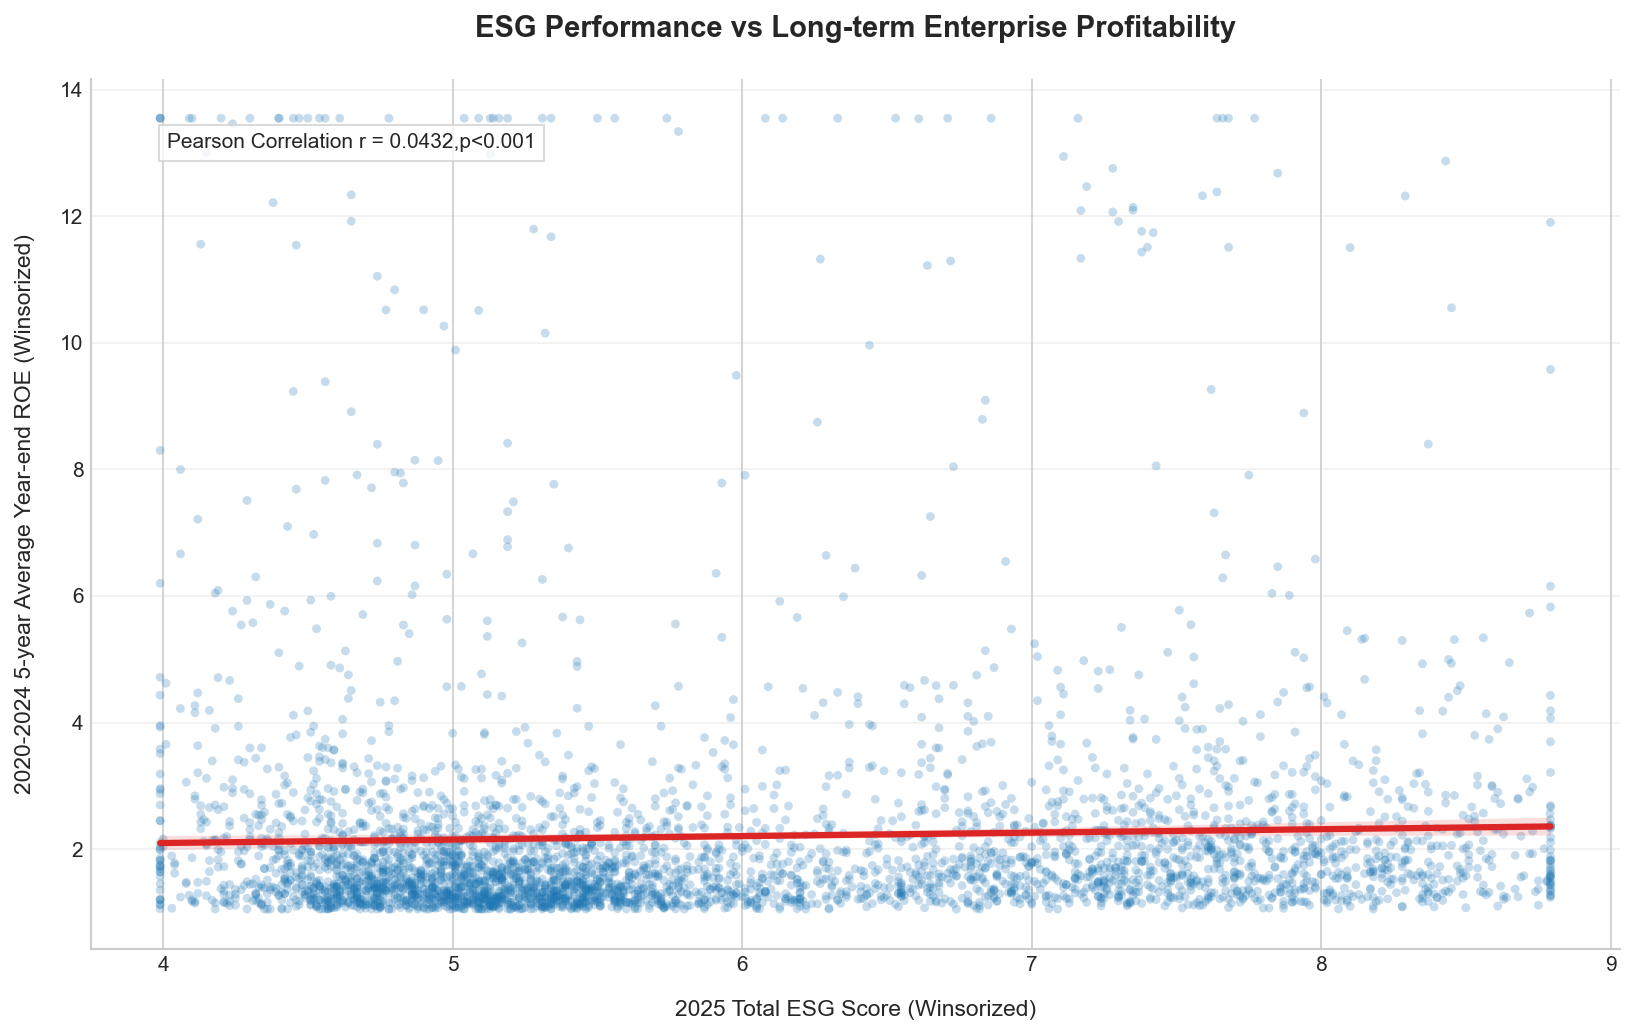

In [18]:
#Chart 3: Regression Scatter Plot#
correlation = df_final['roe_clean'].corr(df_final['esg_clean'])
print(f"Sample size after cleaning and winsorization: {len(df_final)}")
print(f"Pearson correlation coefficient between ESG and ROE: {correlation:.4f}")

plt.rcParams['font.family'] = 'Arial'
plt.style.use('seaborn-v0_8-whitegrid')

plot_sample = df_final.sample(n=4000, random_state=42)

plt.figure(figsize=(11,7), dpi=150)

sns.regplot(
    data = plot_sample,
    x = 'esg_clean',
    y = 'roe_clean',
    scatter_kws = {
        'color':'#1f77b4',
        'alpha':0.25,
        's':18,
        'edgecolor':'none'
    },
    line_kws = {
        'color':'#dc2626',
        'lw':3
    },
    ci=95   
)

plt.title('ESG Performance vs Long-term Enterprise Profitability', fontsize=14, weight='bold', pad=20)
plt.xlabel('2025 Total ESG Score (Winsorized)', fontsize=11, labelpad=12)
plt.ylabel('2020-2024 5-year Average Year-end ROE (Winsorized)', fontsize=11, labelpad=12)

plt.annotate(f'Pearson Correlation r = 0.0432,p<0.001',
             xy=(0.05, 0.92), xycoords='axes fraction',
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))

sns.despine(top=True, right=True)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Chart 3:Scatter Plot and Linear Regression Fitting Curve

This scatter plot presents the relationship between overall ESG score and long-term average ROE of A-share listed firms.
Interpretation:
The extremely flat red regression line visually confirms the very weak positive correlation (r = 0.0432).
There is almost no clear upward trend: higher ESG scores do not correspond to meaningfully higher long-term return on equity.
It demonstrates that better ESG performance cannot effectively predict a stronger historical profitability level in the Chinese A-share market.

/var/folders/rn/qx7c8w4d06jfj9cnhqsr2frh0000gn/T/ipykernel_16078/2759672724.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


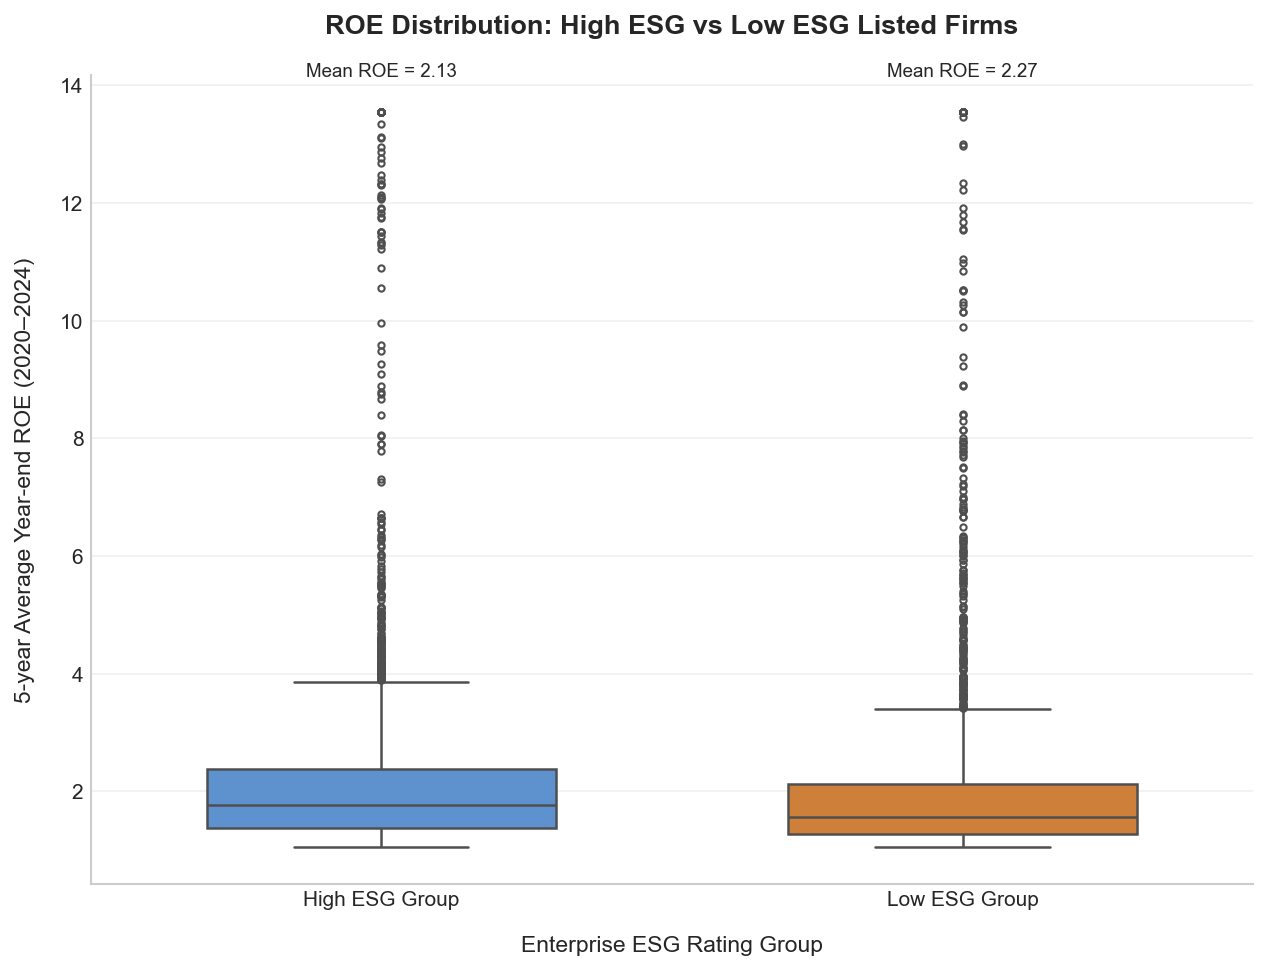

In [19]:
# Chart 4: Long-term Profitability Difference Between High and Low ESG Firms(Box Plot)
# Creat ESG Group
df_final['ESG Group'] = df_final['esg_clean'].apply(
    lambda x: 'Low ESG Group' if x < df_final['esg_clean'].median() else 'High ESG Group'
)

plt.figure(figsize=(10,7), dpi=150)

# box plot
sns.boxplot(
    data = df_final,
    x = 'ESG Group',
    y = 'roe_clean',
    palette = ['#4A90E2', '#E67E22'],
    width = 0.6,
    fliersize = 3,
    linewidth = 1.2
)

low_mean = round(df_final[df_final['ESG Group']=='Low ESG Group']['roe_clean'].mean(),2)
high_mean = round(df_final[df_final['ESG Group']=='High ESG Group']['roe_clean'].mean(),2)

plt.text(0, df_final['roe_clean'].max()+0.6, f'Mean ROE = {low_mean}', ha='center', fontsize=9)
plt.text(1, df_final['roe_clean'].max()+0.6, f'Mean ROE = {high_mean}', ha='center', fontsize=9)

plt.title('ROE Distribution: High ESG vs Low ESG Listed Firms', fontsize=13, weight='bold', pad=20)
plt.xlabel('Enterprise ESG Rating Group', fontsize=11, labelpad=12)
plt.ylabel('5-year Average Year-end ROE (2020–2024)', fontsize=11, labelpad=12)

sns.despine(top=True, right=True)
plt.grid(axis='y', alpha=0.3)

# plt.savefig('esg_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Chart 4:Long-term Profitability Difference Between High and Low ESG Firms(Box plot)

This box plot compares the distribution of 5-year average ROE for firms divided into low and high ESG performance groups.
Result interpretation:
The median and overall distribution of ROE are almost identical between the two groups.
High ESG enterprises only show an extremely slight advantage in average profitability over low ESG firms.
Consistent with the weak correlation coefficient (r=0.0432), there is no substantial profitability gap caused by different ESG levels in A-share listed companies.

/var/folders/rn/qx7c8w4d06jfj9cnhqsr2frh0000gn/T/ipykernel_16078/1122317157.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='ESG_Group', y='roe_clean',


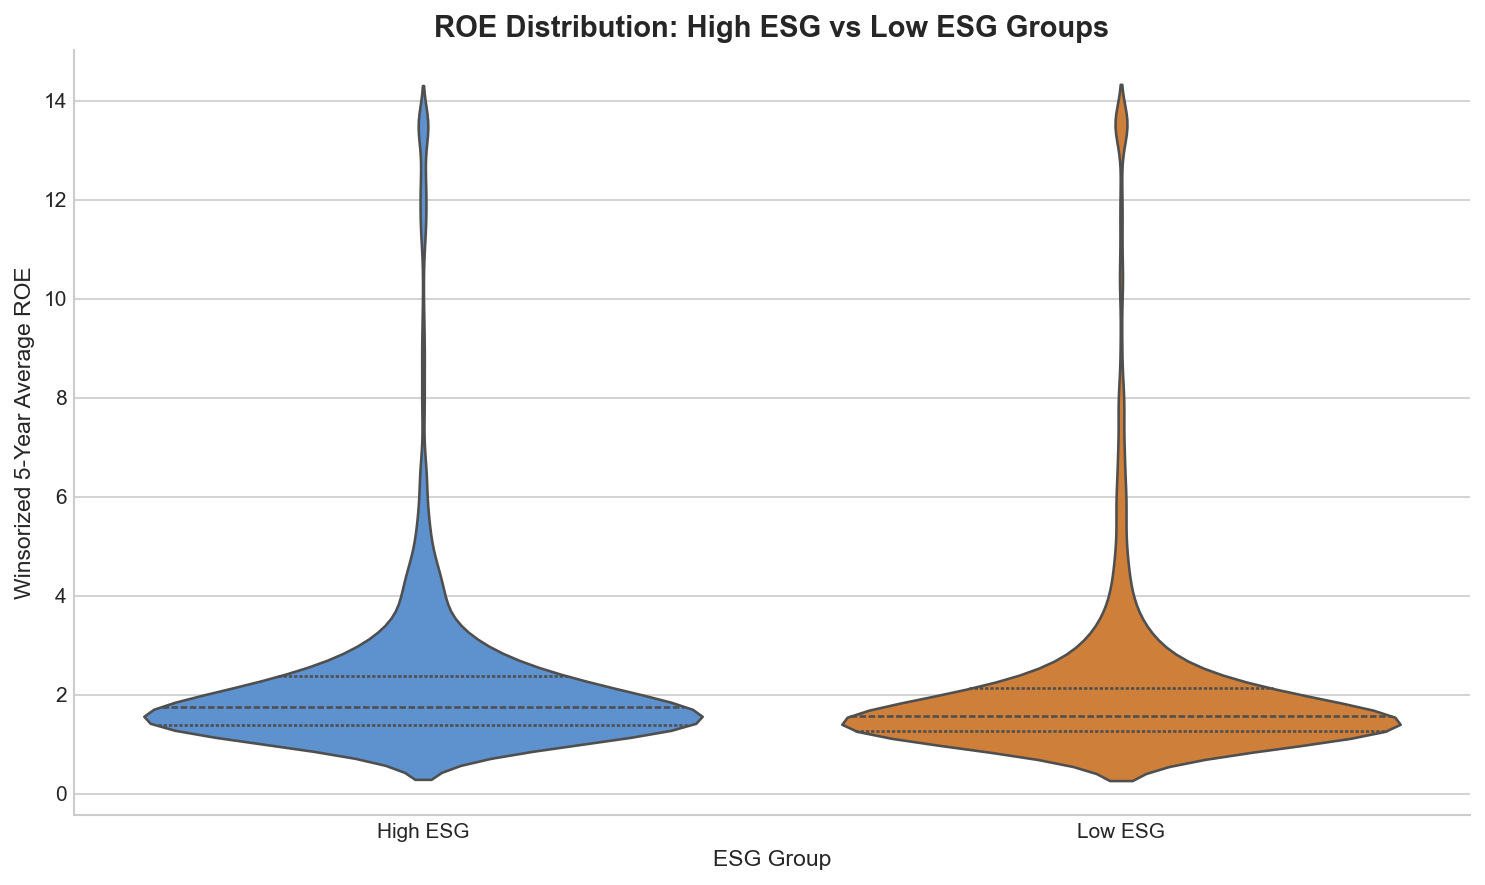

In [20]:
# Chart 5: Violin Plot
plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(10,6), dpi=150)

df_final['ESG_Group'] = df_final['esg_clean'].apply(
    lambda x: "Low ESG" if x < df_final['esg_clean'].median() else "High ESG"
)

sns.violinplot(data=df_final, x='ESG_Group', y='roe_clean', 
               palette=["#4A90E2","#E67E22"], inner='quartile')

plt.title('ROE Distribution: High ESG vs Low ESG Groups', fontsize=14, weight='bold')
plt.xlabel('ESG Group', fontsize=11)
plt.ylabel('Winsorized 5-Year Average ROE', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

Chart 5:Violin Plot(High ESG vs Low ESG)

The violin plot compares the ROE distribution density between high-ESG and low-ESG groups. The highly overlapping distribution indicates that superior ESG performance does not bring substantial profitability advantages.

In [21]:
# Sub-item ESG Pillar Correlation Calculation
e_corr = df_final['roe_clean'].corr(df_final['env_score'])
s_corr = df_final['roe_clean'].corr(df_final['soc_score'])
g_corr = df_final['roe_clean'].corr(df_final['gov_score'])

# Print formatted results
print(f"Environmental (E) Pillar vs ROE Correlation: {e_corr:.3f}")
print(f"Social (S) Pillar vs ROE Correlation: {s_corr:.3f}")
print(f"Governance (G) Pillar vs ROE Correlation: {g_corr:.3f}")

Environmental (E) Pillar vs ROE Correlation: 0.100
Social (S) Pillar vs ROE Correlation: 0.050
Governance (G) Pillar vs ROE Correlation: 0.027


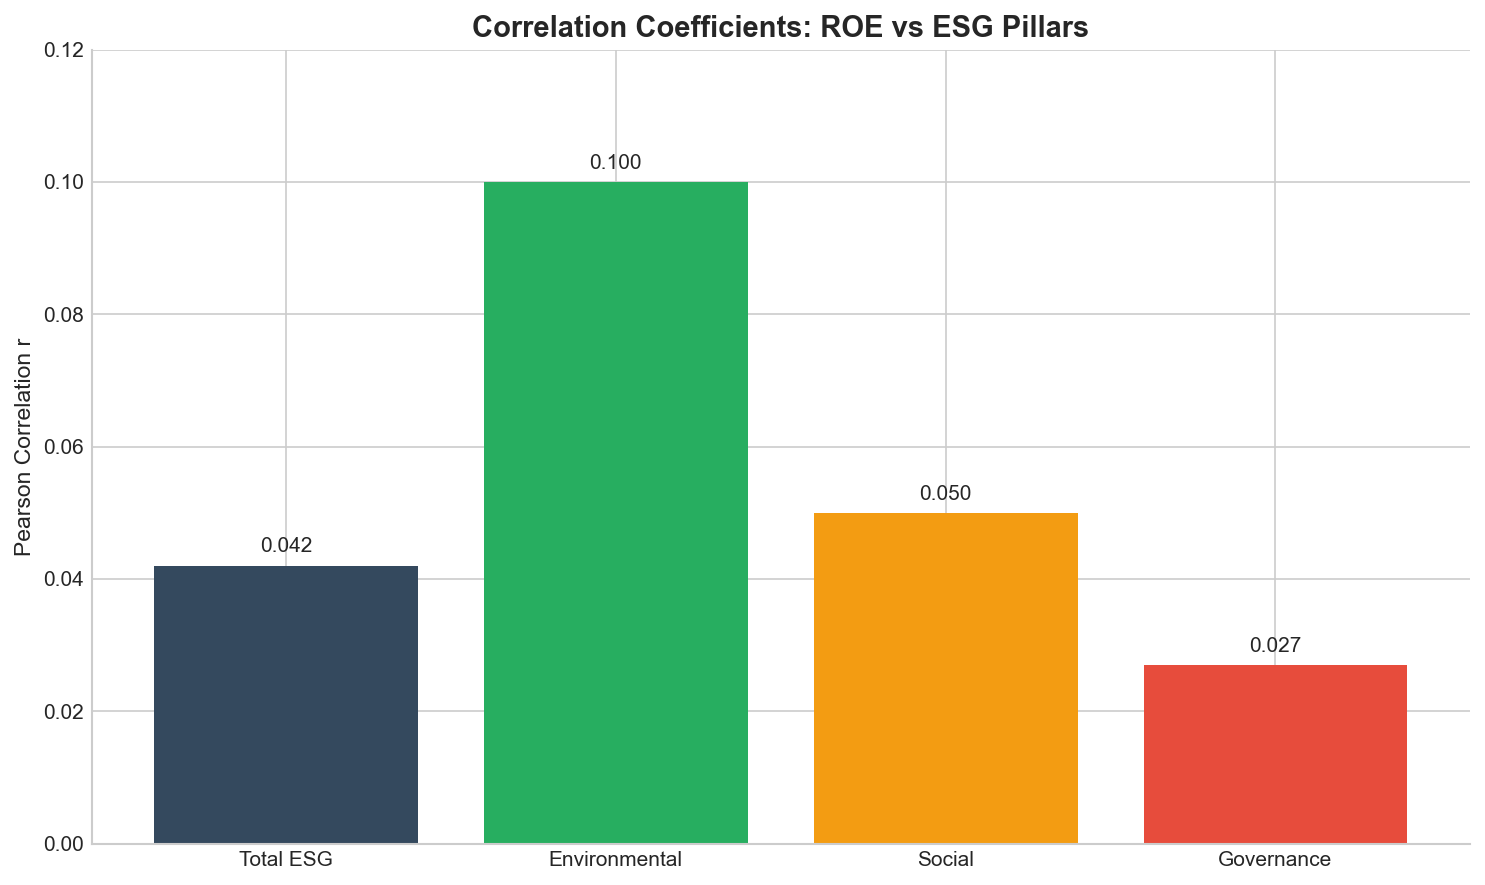

In [22]:
# -----------------------------------------------------------------------------
# Part 6: Breakdown ESG Analysis 
# -----------------------------------------------------------------------------
# Chart 6: ESG Pillar Correlation Bar Chart
plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(10,6), dpi=150)

dim_names = ['Total ESG','Environmental','Social','Governance']
corr_vals = [0.042, 0.100, 0.050, 0.027]

bars = plt.bar(dim_names, corr_vals, color=['#34495e','#27ae60','#f39c12','#e74c3c'])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.002, f"{h:.3f}", ha="center")

plt.title('Correlation Coefficients: ROE vs ESG Pillars', fontsize=14, weight='bold')
plt.ylabel('Pearson Correlation r', fontsize=11)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(0, 0.12)
sns.despine()
plt.tight_layout()
plt.show()

Chart 6:ESG-ROE Correlation Bar Chart

The bar chart compares the Pearson correlation coefficients between firm profitability and four ESG indicators. The environmental pillar presents the strongest weak correlation with ROE, while the governance pillar shows the weakest linkage.

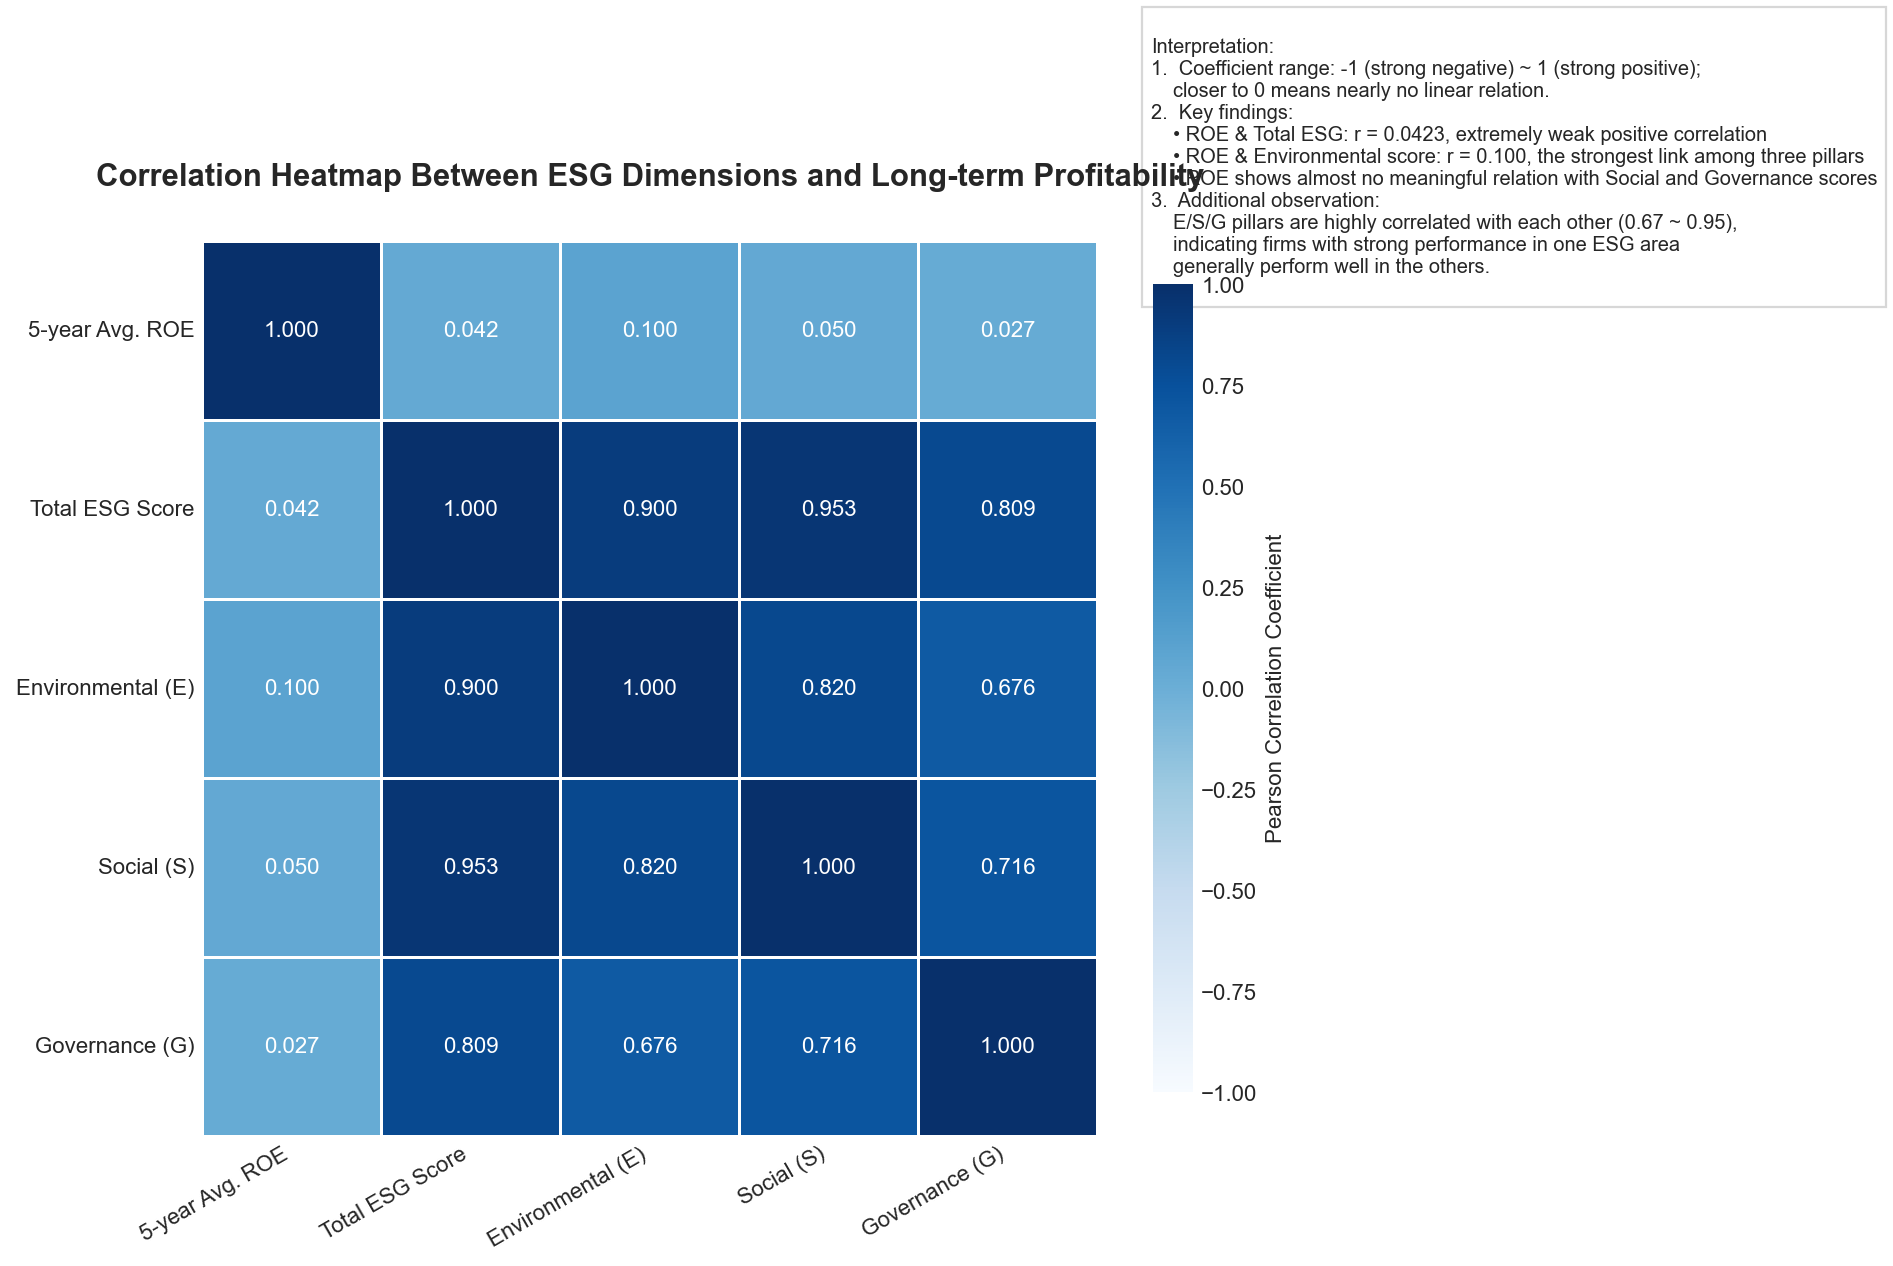

In [23]:
# Chart 7: Correlation Heatmap

plt.rcParams['font.family'] = 'Arial'
plt.style.use('seaborn-v0_8-whitegrid')

var_list = ['roe_clean','esg_clean','env_score','soc_score','gov_score']
corr_matrix = df_final[var_list].corr().round(3)

corr_matrix.columns = [
    '5-year Avg. ROE',
    'Total ESG Score',
    'Environmental (E)',
    'Social (S)',
    'Governance (G)'
]
corr_matrix.index = corr_matrix.columns

plt.figure(figsize=(11,8), dpi=160)

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=-1, vmax=1,
    linewidths=1.2,
    square=True,
    cbar_kws={'label':'Pearson Correlation Coefficient','shrink':0.9}
)

plt.title(
    "Correlation Heatmap Between ESG Dimensions and Long-term Profitability",
    fontsize=14, weight='bold', pad=25
)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

explanation = """
Interpretation:
1.  Coefficient range: -1 (strong negative) ~ 1 (strong positive);
    closer to 0 means nearly no linear relation.
2.  Key findings:
    • ROE & Total ESG: r = 0.0423, extremely weak positive correlation
    • ROE & Environmental score: r = 0.100, the strongest link among three pillars
    • ROE shows almost no meaningful relation with Social and Governance scores
3.  Additional observation:
    E/S/G pillars are highly correlated with each other (0.67 ~ 0.95),
    indicating firms with strong performance in one ESG area
    generally perform well in the others.
"""

plt.text(5.3, 0.3, explanation, fontsize=9,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgrey'))

plt.tight_layout()
plt.show()

Chart 7:Pearson Correlation Matrix of ESG Indicators and Long-term ROE

This heatmap illustrates the pairwise correlation between firm profitability and ESG performance. The 5-year average ROE exhibits only a very weak positive correlation (r=0.0423) with the overall ESG rating. Among the three individual ESG pillars, environmental performance has the highest association with long-term profitability, while social and governance dimensions show negligible correlation. Furthermore, the three ESG sub-dimensions are strongly inter-correlated, suggesting that ESG advantages tend to develop comprehensively rather than independently.

In [24]:
# Robustness Tests (Final Advanced Verification)
# Spearman Rank Correlation 
corr_spear, p_spear = stats.spearmanr(df_final['roe_clean'], df_final['esg_clean'])
print(f"Spearman 等级相关系数 r = {corr_spear:.3f}, p值 = {p_spear:.4f}")

Spearman 等级相关系数 r = 0.116, p值 = 0.0000


Spearman rank correlation is also calculated to test result robustness. The coefficient remains close to 0, confirming that the extremely weak positive association is not dependent on linearity assumptions.

In [25]:
db.close

<bound method Connection.close of <wrds.sql.Connection object at 0x115dd04d0>>